# Оценка качества модели
Этот ноутбук выполняет качественную оценку обученной модели на валидационной выборке без необходимости повторного обучения.

In [1]:
import os
import random
import time
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import kagglehub
import kagglehub.cache
import kagglehub.handle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, log_loss
import timm
from torch.amp import autocast
from tqdm.auto import tqdm

SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = 0
TEST_SIZE = 0.2
IMAGE_SIZE = 224
NUM_CLASSES = 120
MODEL_NAME = "tf_efficientnetv2_s"
DATASET_NAME = "dog-breed-identification"

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Загрузка и настройка датасета

In [2]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("API-токен Kaggle не найден.")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
TRAIN_DIR = DATA_DIR / "train"
LABELS_CSV = DATA_DIR / "labels.csv"

## 2. Подготовка валидационной выборки

In [3]:
df = pd.read_csv(LABELS_CSV)
breeds = sorted(df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breeds)}
idx_to_breed = {i: b for i, b in enumerate(breeds)}
df["label"] = df["breed"].map(breed_to_idx)

_, val_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=SEED
)

## 3. Проверка распределения классов

In [4]:
val_counts = val_df["breed"].value_counts()
print(f"Размер валидационной выборки: {val_df.shape[0]}")
print(f"Минимум изображений на породу в Validation Set: {val_counts.min()}")
print(f"Максимум изображений на породу в Validation Set: {val_counts.max()}")

Размер валидационной выборки: 2045
Минимум изображений на породу в Validation Set: 13
Максимум изображений на породу в Validation Set: 25


## 4. Создание датасета и загрузчика

In [5]:
class DogDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.ids = df["id"].values
        self.labels = df["label"].values if "label" in df.columns else None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = f"{self.ids[idx]}.jpg"
        img_path = self.img_dir / img_name
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        return image, self.ids[idx]

val_transforms = transforms.Compose([
    transforms.Resize((int(IMAGE_SIZE * 256 / 224), int(IMAGE_SIZE * 256 / 224))),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_dataset = DogDataset(val_df, TRAIN_DIR, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## 5. Загрузка модели из чекпоинта

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path):

## 6. Получение предсказаний и измерение Latency

In [7]:
all_preds = []
all_labels = []
all_probs = []
inference_times = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Оценка на валидационной выборке"):
        images = images.to(device, non_blocking=True)
        
        start_time = time.perf_counter()
        with autocast("cuda"):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        end_time = time.perf_counter()
        
        inference_times.append(end_time - start_time)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

avg_batch_time = np.mean(inference_times)
avg_image_time = avg_batch_time / BATCH_SIZE
throughput = 1.0 / avg_image_time

print(f"Average Batch Inference Latency: {avg_batch_time * 1000:.2f} ms")
print(f"Average Image Inference Latency: {avg_image_time * 1000:.2f} ms")
print(f"Throughput: {throughput:.2f} images/second")

Оценка на валидационной выборке:   0%|          | 0/64 [00:00<?, ?it/s]

Average Batch Inference Latency: 62.23 ms
Average Image Inference Latency: 1.94 ms
Throughput: 514.22 images/second


## 7. Расчет метрик качества

In [8]:
val_acc = np.mean(all_preds == all_labels)
val_logloss = log_loss(all_labels, all_probs, labels=np.arange(NUM_CLASSES))

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Log Loss: {val_logloss:.4f}")

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=breeds,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
breed_metrics = report_df.iloc[:-3].copy()

top_10_easy = breed_metrics.sort_values(by="f1-score", ascending=False).head(10)
print("Топ-10 пород с наивысшим F1-Score:")
display(top_10_easy[["precision", "recall", "f1-score"]])

top_10_hard = breed_metrics.sort_values(by="f1-score", ascending=True).head(10)
print("Топ-10 пород с наименьшим F1-Score:")
display(top_10_hard[["precision", "recall", "f1-score"]])

Validation Accuracy: 0.6993
Validation Log Loss: 1.0334
Топ-10 пород с наивысшим F1-Score:


,precision,recall,f1-score
leonberg,1.000000,0.952381,0.975610
saint_bernard,1.000000,0.941176,0.969697
irish_water_spaniel,1.000000,0.937500,0.967742
dhole,1.000000,0.933333,0.965517
english_setter,0.941176,0.941176,0.941176
keeshond,1.000000,0.875000,0.933333
bedlington_terrier,0.857143,1.000000,0.923077
komondor,0.923077,0.923077,0.923077
bernese_mountain_dog,0.913043,0.913043,0.913043
african_hunting_dog,0.937500,0.882353,0.909091


Топ-10 пород с наименьшим F1-Score:


,precision,recall,f1-score
walker_hound,0.250000,0.142857,0.181818
standard_schnauzer,0.500000,0.142857,0.222222
collie,0.600000,0.176471,0.272727
eskimo_dog,0.600000,0.230769,0.333333
kelpie,0.800000,0.235294,0.363636
standard_poodle,0.666667,0.250000,0.363636
labrador_retriever,0.500000,0.294118,0.370370
lhasa,0.347826,0.444444,0.390244
american_staffordshire_terrier,0.800000,0.266667,0.400000
malamute,0.461538,0.375000,0.413793


## 8. Анализ наиболее частых ошибок (Confusion Matrix Analysis)

In [9]:
confusion_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_labels, all_preds):
    confusion_matrix[t, p] += 1

confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and confusion_matrix[i, j] > 0:
            confused_pairs.append((idx_to_breed[i], idx_to_breed[j], confusion_matrix[i, j]))

confused_pairs = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

confused_pairs_df = pd.DataFrame(confused_pairs[:10], columns=["Истинная порода", "Предсказанная порода", "Количество ошибок"])
print("Топ-10 наиболее часто путаемых пар пород:")
display(confused_pairs_df)

Топ-10 наиболее часто путаемых пар пород:


,Истинная порода,Предсказанная порода,Количество ошибок
0,scottish_deerhound,irish_wolfhound,11
1,shih-tzu,lhasa,10
2,collie,shetland_sheepdog,8
3,eskimo_dog,siberian_husky,8
4,norwich_terrier,norfolk_terrier,8
5,malamute,siberian_husky,7
6,standard_poodle,miniature_poodle,7
7,standard_schnauzer,miniature_schnauzer,7
8,walker_hound,basset,7
9,american_staffordshire_terrier,staffordshire_bullterrier,6


## 9. Визуализация правильных и ошибочных предсказаний

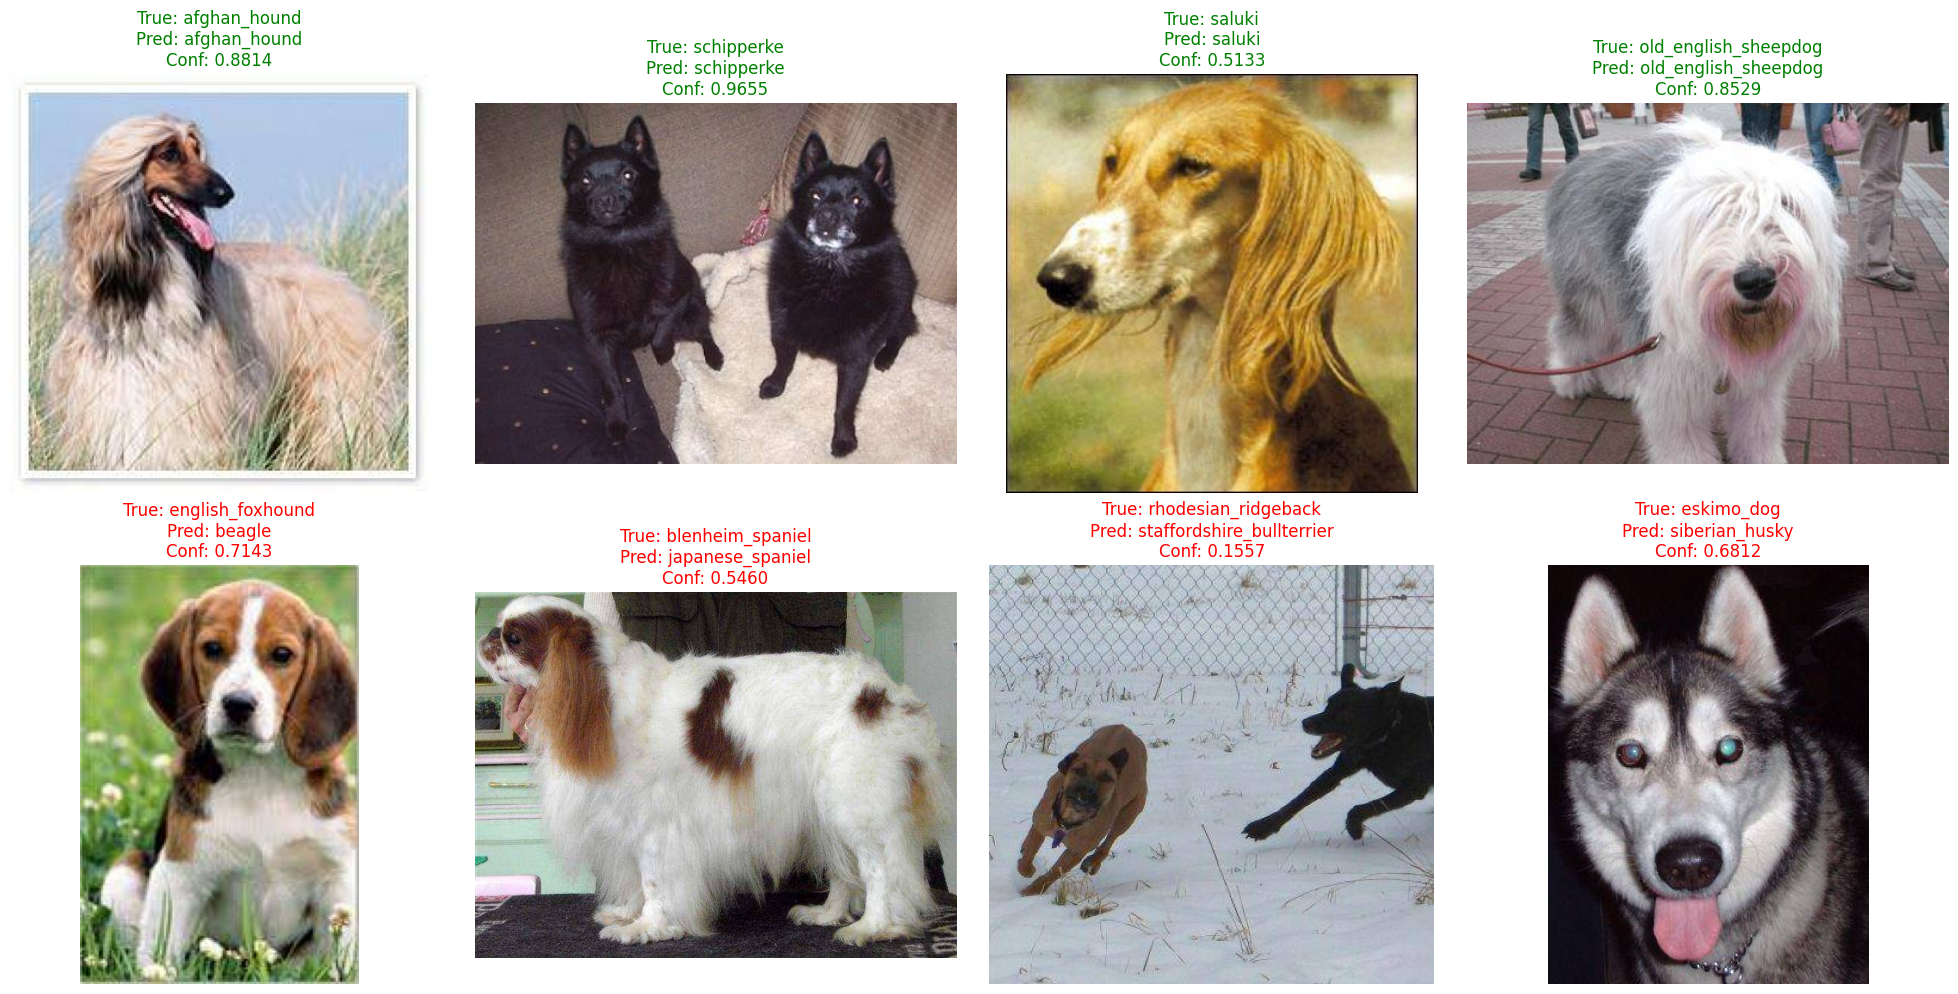

In [10]:
val_df_with_preds = val_df.copy()
val_df_with_preds["predicted_label"] = all_preds
val_df_with_preds["predicted_breed"] = val_df_with_preds["predicted_label"].map(idx_to_breed)
val_df_with_preds["confidence"] = [probs[p] for probs, p in zip(all_probs, all_preds)]
val_df_with_preds["correct"] = val_df_with_preds["label"] == val_df_with_preds["predicted_label"]

correct_samples = val_df_with_preds[val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[val_df_with_preds["correct"]])), random_state=SEED)
incorrect_samples = val_df_with_preds[~val_df_with_preds["correct"]].sample(n=min(4, len(val_df_with_preds[~val_df_with_preds["correct"]])), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, (_, row) in enumerate(correct_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[0, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="green")

for i, (_, row) in enumerate(incorrect_samples.iterrows()):
    img_path = TRAIN_DIR / f"{row['id']}.jpg"
    img = Image.open(img_path)
    ax = axes[1, i]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {row['breed']}\nPred: {row['predicted_breed']}\nConf: {row['confidence']:.4f}", color="red")
plt.tight_layout()
plt.show()